In [9]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import matplotlib.pyplot as plt

In [ ]:
# load shapefile data

gdf = gpd.read_file("./tl_2021_us_state/tl_2021_us_state.shp")

In [3]:
gdf.keys()

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'STUSPS', 'NAME',
       'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'geometry'],
      dtype='object')

In [ ]:
# filter out non us states
state_fips_exclude = ['60', '66', '69', '72', '78', '02', '15']  # American Samoa, Guam, N. Mariana, Puerto Rico, Virgin Islands 
# removed: Alaska, Hawaii
gdf = gdf[~gdf['STATEFP'].isin(state_fips_exclude)].reset_index(drop=True)

In [6]:
# make binary adjacency matrix based on border presence

n = len(gdf)
A = np.zeros((n,n), dtype=int) # initialize adjacency matrix

for i in range(n):
    for j in range(i+1,n):
        if gdf.geometry[i].touches(gdf.geometry[j]):
            A[i,j] = 1
            A[j,i] = 1 #symmetric


In [7]:
# make dataframe

states_names = gdf["STUSPS"].values

df = pd.DataFrame(A, index=states_names, columns=states_names)

In [ ]:
# save

df.to_csv("adj_border.csv")

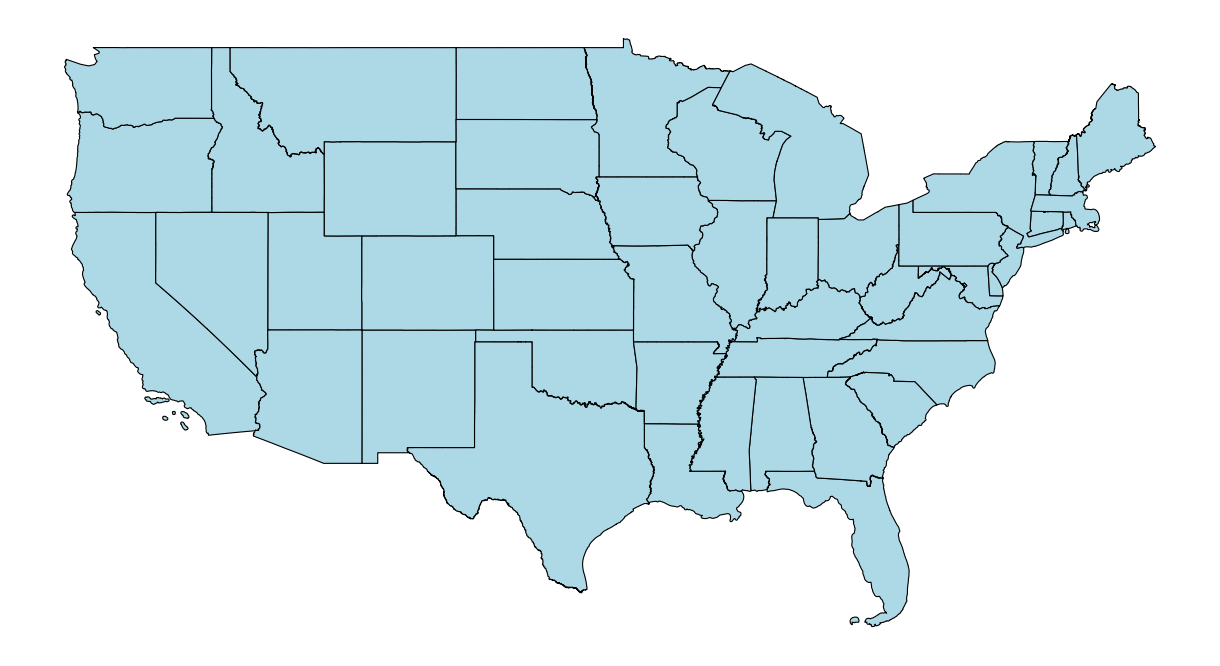

In [13]:
# plot borders

# Create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the map
gdf.plot(
    ax=ax,
    edgecolor='black',        # border color
    facecolor='lightblue',        # fill color for states
    linewidth=0.8             # border thickness
)

# Remove axes for a clean map
ax.set_axis_off()

# Set transparent background
fig.patch.set_alpha(0.0)     # transparent figure background
ax.set_facecolor("none")     # transparent map area

# Optional: adjust padding
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.show()


In [9]:
# DISTANCE-WEIGHTED VARIANT

# Compute centroids (latitude, longitude)
centroids = gdf.geometry.centroid

n = len(gdf)
dist_matrix = np.zeros((n, n))

# Convert to meters using a projected CRS (meters, not degrees)
gdf_proj = gdf.to_crs(epsg=3395)  # Mercator projection in meters
centroids_proj = gdf_proj.geometry.centroid

for i in range(n):
    for j in range(n):
        if i != j:
            dist_matrix[i, j] = centroids_proj.iloc[i].distance(centroids_proj.iloc[j]) / 1000  # km

/tmp/ipykernel_59695/2687522772.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


In [10]:
# Compute the mean or median centroid-to-centroid distance between neighbors to get characteristic length in km (heuristic for all USA 500)

neighbor_distances = []
for i in range(n):
    for j in range(n):
        if i != j and A[i,j] == 1:  # only bordering states
            neighbor_distances.append(dist_matrix[i,j])

r = np.mean(neighbor_distances)

# Compute exponential decay
weight_matrix = np.exp(-dist_matrix / r)

# set diagonal to 0
np.fill_diagonal(weight_matrix, 0)

In [11]:
df_dist = pd.DataFrame(weight_matrix, index=states_names, columns=states_names)

df_dist.to_csv("adj_dist.csv")

In [ ]:
# Variant used by STAN
# w_ij = p_i ^alpha * p_i^beta * exp(-d_ij/r)

df_pop = pd.read_csv("us_pop_by_state.csv")

df_pop_filter = df_pop[df_pop["state_code"].isin(states_names)]

# Make sure 'State' is the index
df_pop_tmp = df_pop_filter.set_index("state_code")

# Reorder rows to match the desired order
df_pop_order = df_pop_tmp.loc[states_names]

In [29]:
populations = df_pop_order["2020_census"].tolist()

In [31]:
# Hyperparameters
alpha = 0.5
beta = 0.5
r = 500  # km

# Compute centroids in projected CRS for distances
gdf_proj = gdf.to_crs(epsg=3395)
centroids = gdf_proj.geometry.centroid

n = len(gdf)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            dist_matrix[i, j] = centroids.iloc[i].distance(centroids.iloc[j]) / 1000  # km

# Compute weighted adjacency
w_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            w_matrix[i, j] = (populations[i]**alpha) * (populations[j]**beta) * np.exp(-dist_matrix[i,j]/r)

# Optional: set diagonal to 0
np.fill_diagonal(w_matrix, 0)

In [32]:
df_w_mat = pd.DataFrame(w_matrix, index=states_names, columns=states_names)
df_w_mat.to_csv("adj_pop_dist.csv")